<a href="https://colab.research.google.com/github/Swayam17o5/DL1/blob/main/GAN1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded MNIST dataset with 60000 samples.
Using device: cuda
Starting Training...
Epoch [0/15] Batch [0/938] Loss D: 1.5102, Loss G: 0.8435
Epoch [0/15] Batch [100/938] Loss D: 0.0136, Loss G: 5.2563
Epoch [0/15] Batch [200/938] Loss D: 0.5818, Loss G: 3.6833
Epoch [0/15] Batch [300/938] Loss D: 0.4397, Loss G: 1.6389
Epoch [0/15] Batch [400/938] Loss D: 0.3874, Loss G: 1.6533
Epoch [0/15] Batch [500/938] Loss D: 0.3181, Loss G: 2.2885
Epoch [0/15] Batch [600/938] Loss D: 0.3759, Loss G: 1.5429
Epoch [0/15] Batch [700/938] Loss D: 0.2647, Loss G: 2.4798
Epoch [0/15] Batch [800/938] Loss D: 0.1567, Loss G: 2.9969
Epoch [0/15] Batch [900/938] Loss D: 0.2118, Loss G: 1.9098
Epoch [1/15] Batch [0/938] Loss D: 0.3102, Loss G: 1.4842
Epoch [1/15] Batch [100/938] Loss D: 0.1860, Loss G: 3.0274
Epoch [1/15] Batch [200/938] Loss D: 0.3437, Loss G: 4.7139
Epoch [1/15] Batch [300/938] Loss D: 0.1661, Loss G: 3.1650
Epoch [1/15] Batch [400/938] Loss D: 0.1849, Loss G: 3.1248
Epoch [1/15] Batch [500

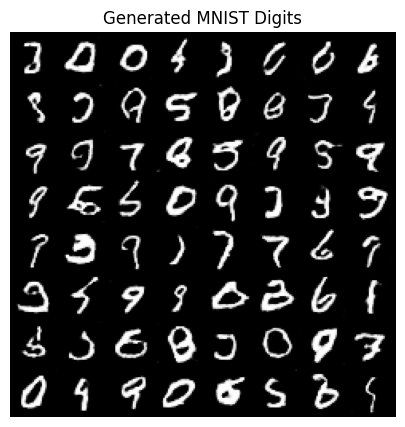

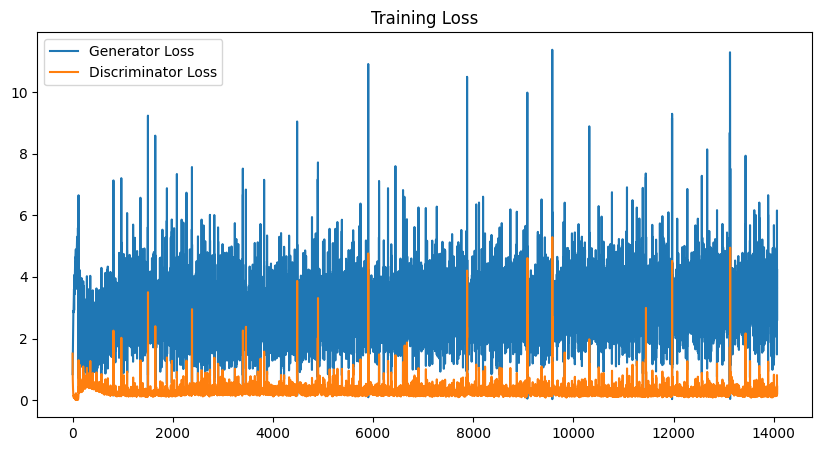

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import time


batch_size = 64
data_root = './data'

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root=data_root,
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Loaded MNIST dataset with {len(train_dataset)} samples.")


latent_dim = 100
img_channels = 1
img_size = 28
lr = 0.0002
beta1 = 0.5
num_epochs = 15

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            nn.Linear(latent_dim, 128 * 7 * 7),
            nn.BatchNorm1d(128 * 7 * 7),
            nn.ReLU(True),

            nn.Unflatten(1, (128, 7, 7)),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 14x14
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),    # 28x28
            nn.Tanh()
        )

    def forward(self, z):
        return self.main(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),   # 14x14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1), # 7x7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.main(x)


gen = Generator().to(device)
disc = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_g = optim.Adam(gen.parameters(), lr=lr, betas=(beta1, 0.999))
optimizer_d = optim.Adam(disc.parameters(), lr=lr, betas=(beta1, 0.999))

# Fixed noise for visualization
fixed_noise = torch.randn(64, latent_dim, device=device)

# Track losses
g_losses = []
d_losses = []
img_list = []

print("Starting Training...")

start_time = time.time()


for epoch in range(num_epochs):
    for i, (real_imgs, _) in enumerate(train_loader):

        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        disc.zero_grad()

        real_labels = torch.ones(b_size, device=device)
        fake_labels = torch.zeros(b_size, device=device)

        # Real loss
        output_real = disc(real_imgs).view(-1)
        loss_real = criterion(output_real, real_labels)

        # Fake loss
        noise = torch.randn(b_size, latent_dim, device=device)
        fake_imgs = gen(noise)

        output_fake = disc(fake_imgs.detach()).view(-1)
        loss_fake = criterion(output_fake, fake_labels)

        loss_d = loss_real + loss_fake
        loss_d.backward()
        optimizer_d.step()


        gen.zero_grad()

        output = disc(fake_imgs).view(-1)
        loss_g = criterion(output, real_labels)

        loss_g.backward()
        optimizer_g.step()


        g_losses.append(loss_g.item())
        d_losses.append(loss_d.item())

        if i % 100 == 0:
            print(f"Epoch [{epoch}/{num_epochs}] Batch [{i}/{len(train_loader)}] "
                  f"Loss D: {loss_d.item():.4f}, Loss G: {loss_g.item():.4f}")


        if (i % 500 == 0) or ((epoch == num_epochs-1) and (i == len(train_loader)-1)):
            with torch.no_grad():
                fake = gen(fixed_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, normalize=True))


end_time = time.time()
print(f"Training Time: {(end_time - start_time)/60:.2f} minutes")


plt.figure(figsize=(10,5))
plt.imshow(np.transpose(img_list[-1], (1,2,0)))
plt.title("Generated MNIST Digits")
plt.axis('off')
plt.show()


plt.figure(figsize=(10,5))
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.legend()
plt.title("Training Loss")
plt.show()

In [ ]:
🔹 1. Purpose of the Code
This program implements a GAN (Generative Adversarial Network) using PyTorch
It is trained on the MNIST dataset
Goal: generate realistic handwritten digits (0–9)
🔹 2. Data Loading & Preprocessing
MNIST dataset is loaded using torchvision.datasets
Each image is:
Converted to tensor
Normalized from [0,1] → [-1,1]
Data is passed in batches using DataLoader

👉 Why normalization?

Because the generator uses tanh activation, which outputs values in [-1,1]

🔹 3. GAN Concept (MOST IMPORTANT)
The model has 2 networks:
Generator (G)
Takes random noise (100-d vector)
Generates fake digit images
Discriminator (D)
Takes an image (real or fake)
Outputs probability:
1 → real
0 → fake

👉 They compete:

Generator tries to fool Discriminator
Discriminator tries to detect fake images

🔹 4. Generator Architecture
Input: random noise (size = 100)
Fully connected layer → reshape → convolution layers
Uses:
BatchNorm → stabilizes training
ReLU → activation
ConvTranspose2d → upsampling

👉 Output:

Image of size 28×28
Activation: tanh
🔹 5. Discriminator Architecture
Input: image (28×28)
Uses convolution layers to extract features
Uses:
LeakyReLU → prevents dead neurons
BatchNorm → improves stability

👉 Output:

Single value (real/fake probability using sigmoid)
🔹 6. Loss Function & Optimizer
Loss: Binary Cross Entropy (BCE)
Optimizer: Adam
Learning rate = 0.0002
Beta1 = 0.5 (important for GAN stability)
🔹 7. Training Process (CORE LOGIC)

For each batch:

Step 1: Train Discriminator
Give real images → label = 1
Give fake images → label = 0
Compute loss and update discriminator
Step 2: Train Generator
Generate fake images
Try to fool discriminator → label = 1
Update generator weights

👉 Key idea:

Discriminator learns to detect fakes
Generator learns to produce better fakes

🔹 8. Monitoring Training
Losses stored:
Generator loss
Discriminator loss
Printed every 100 batches
🔹 9. Image Generation
Fixed noise is used to:
Generate images during training
Track progress visually
🔹 10. Output Visualization
Final generated digits are displayed
Loss graph shows:
Training behavior of G and D